In [1]:
# /scripts/road_length_per_hex.py

from srai.loaders import OSMWayLoader, OSMNetworkType
from srai.regionalizers import geocode_to_region_gdf, H3Regionalizer
import geopandas as gpd
import matplotlib.pyplot as plt


In [2]:

# Step 1: Get region boundary
area = geocode_to_region_gdf("Hokkaido, Japan")


/home/eliviau/miniconda3/envs/hex2vec_env/lib/python3.9/site-packages/networkx/utils/backends.py:135: RuntimeWarning: networkx backend defined more than once: nx-loopback
  backends.update(_get_backends("networkx.backends"))


In [3]:
# Step 2: Load road data
loader = OSMWayLoader(OSMNetworkType.DRIVE)  # can also use ALL
_, roads = loader.load(area)  # use 'edges' only



/home/eliviau/miniconda3/envs/hex2vec_env/lib/python3.9/site-packages/osmnx/_overpass.py:267: UserWarning: This area is 74 times your configured Overpass max query area size. It will automatically be divided up into multiple sub-queries accordingly. This may take a long time.
  multi_poly_proj = utils_geo._consolidate_subdivide_geometry(poly_proj)


  0%|          | 0/12 [00:00<?, ?it/s]

In [4]:



# Step 3: Generate hexagons
regionalizer = H3Regionalizer(resolution=7)
regions = regionalizer.transform(area)


In [5]:
# Step 4: Reproject to metric CRS (EPSG:3857)
regions_proj = regions.to_crs("EPSG:3857")
roads_proj = roads.to_crs("EPSG:3857")


In [6]:
# Step 5: Compute road length per segment
roads_proj["length_m"] = roads_proj.geometry.length


In [7]:
# Step 6: Spatial join to assign roads into hexes
joined = gpd.sjoin(roads_proj, regions_proj, predicate="intersects", how="inner")


In [8]:

# Step 7: Aggregate total road length per hex
lengths_per_hex = joined.groupby("region_id")["length_m"].sum()



In [12]:
regions = regions.reset_index()  # ensures 'region_id' becomes a column


In [13]:
regions.head()

,region_id,geometry
0,872e1bb05ffffff,"POLYGON ((141.02832 42.42758, 141.02413 42.439..."
1,872ef415effffff,"POLYGON ((141.48608 43.86309, 141.48187 43.875..."
2,872ef4690ffffff,"POLYGON ((141.4078 44.51549, 141.40353 44.5276..."
3,872e1e645ffffff,"POLYGON ((143.06589 42.7557, 143.06197 42.7681..."
4,872ea9cb2ffffff,"POLYGON ((143.58632 44.41595, 143.58238 44.428..."


In [11]:
joined.head()

,oneway,lanes-1,lanes-2,lanes-3,lanes-4,lanes-5,lanes-6,lanes-7,lanes-8,lanes-9,...,lit-no,lit-sunset-sunrise,lit-24/7,lit-automatic,lit-disused,lit-limited,lit-interval,geometry,length_m,region_id
feature_id,,,,,,,,,,,,,,,,,,,,,
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,"LINESTRING (15587954.85 5080822.398, 15588001....",70.228110,872ee4c2cffffff
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,"LINESTRING (15588357.203 5081315.78, 15588351....",569.319503,872ee4c2cffffff
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,"LINESTRING (15588357.203 5081315.78, 15588351....",569.319503,872ee4c2effffff
2,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,"LINESTRING (15588049.138 5080776.437, 15588026...",109.843828,872ee4c2cffffff
3,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,"LINESTRING (15588222.217 5081421.225, 15588208...",605.482780,872ee4c2cffffff


In [14]:

# Step 8: Assign back to regions
regions["road_length_km"] = regions["region_id"].map(lengths_per_hex / 1000)  # convert m to km
regions["road_length_km"] = regions["road_length_km"].fillna(0)


In [15]:


# Optional: Normalize by hex area to get density
regions["area_km2"] = regions_proj.geometry.area / 1e6
regions["road_density_km_per_km2"] = regions["road_length_km"] / regions["area_km2"]


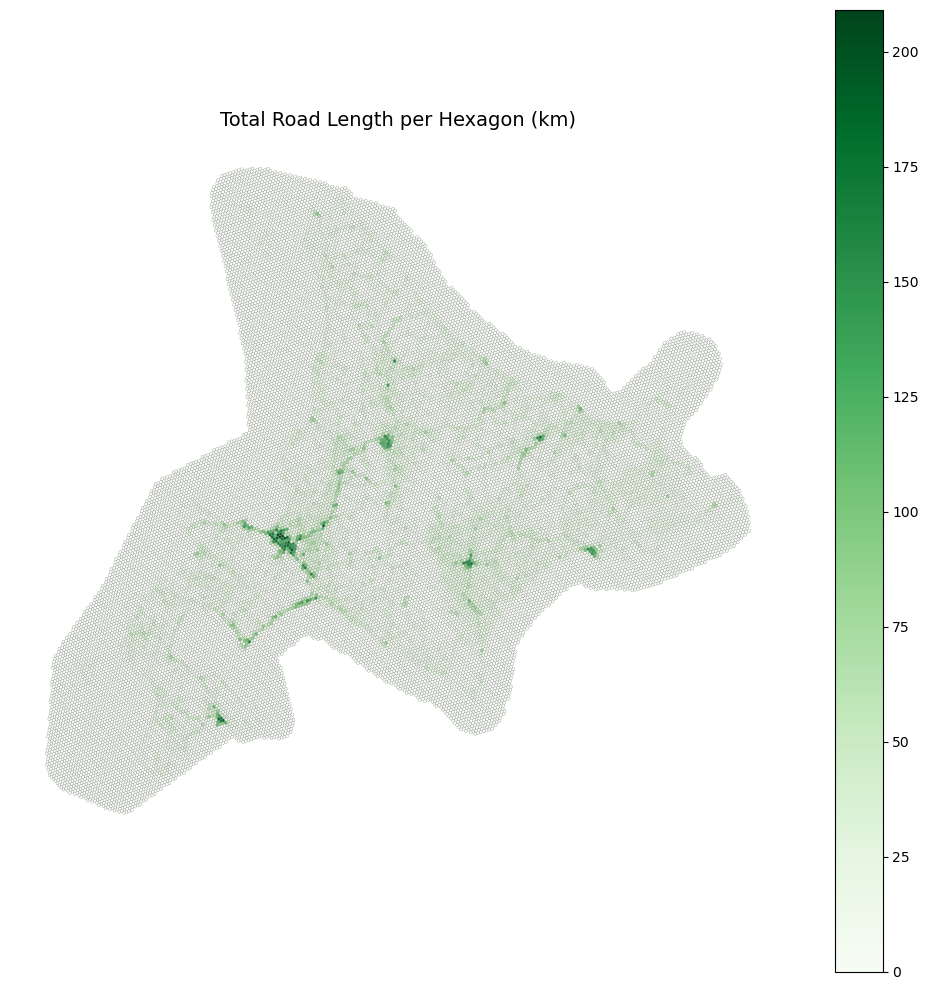

In [20]:

# Step 9: Plot
fig, ax = plt.subplots(figsize=(10, 10))
regions.plot(column="road_length_km", cmap="Greens", legend=True, ax=ax, edgecolor="grey", linewidth=0.2)
ax.set_title("Total Road Length per Hexagon (km)", fontsize=14)
ax.axis("off")
plt.tight_layout()
plt.show()


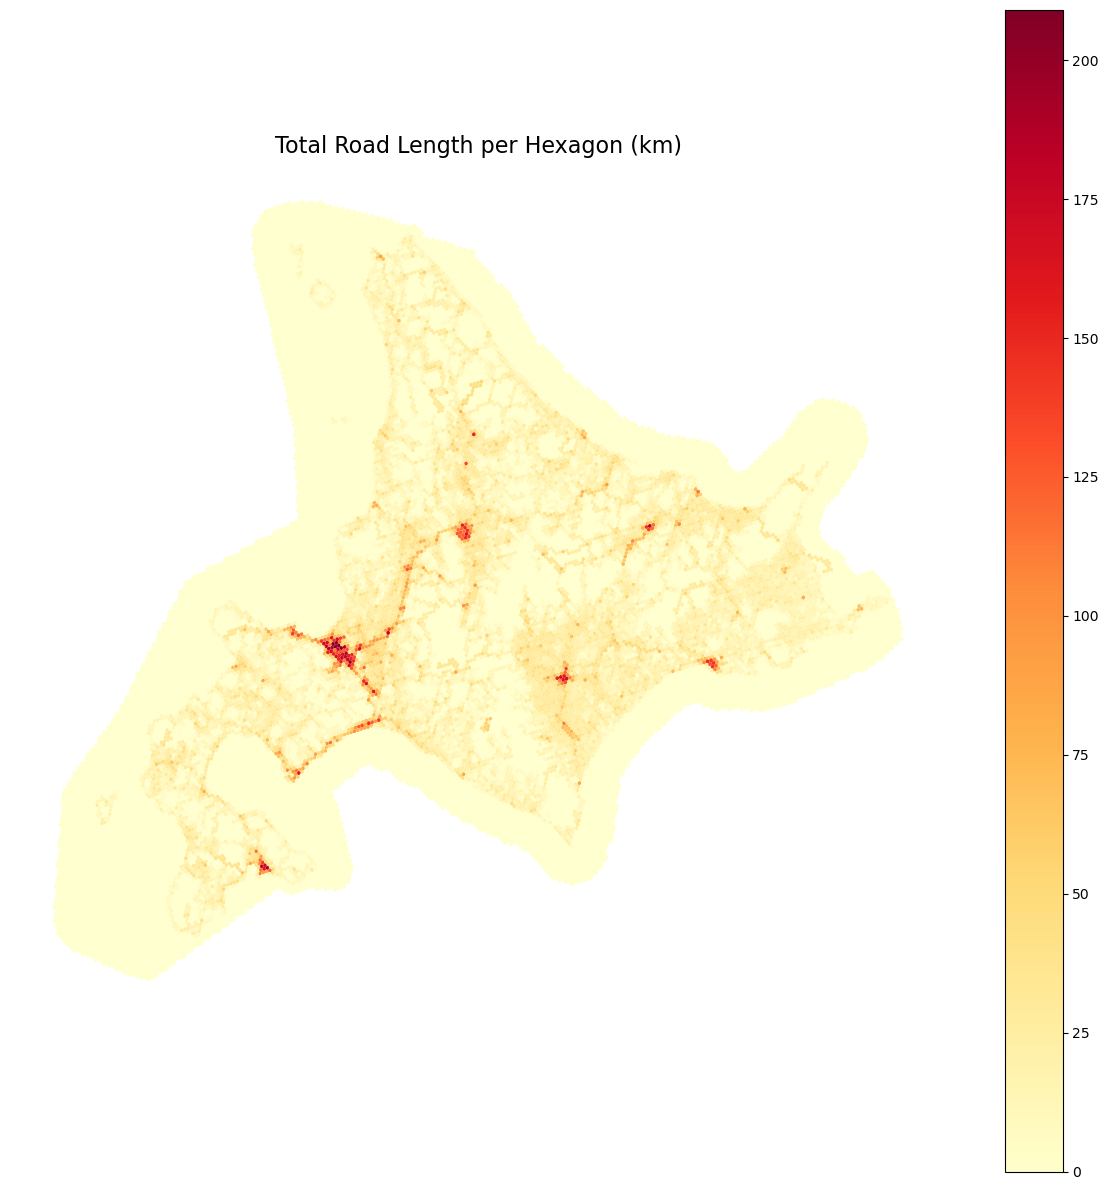

In [21]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 12))

# Use better style and color
regions.plot(
    column="road_length_km",
    cmap="YlOrRd",                # brighter and intuitive
    legend=True,
    ax=ax,
    edgecolor="none",            # remove borders
    linewidth=0,
)

ax.set_title("Total Road Length per Hexagon (km)", fontsize=16)
ax.set_axis_off()
plt.tight_layout()
plt.show()


In [18]:
##add powerplants locations of my map 

from srai.plotting import plot_numeric_data

#remettre le index 
regions = regions.set_index("region_id")  #Can only be run once. If theres an error, restart kernel and run this cell without running the previous map one

m = plot_numeric_data(regions, "road_length_km", colormap="plasma", opacity=0.6)
#power_plants.explore(m=m, color='black')
m.save("road_density_first_map_map.html")

In [24]:
regions.head()

,geometry,road_length_km,area_km2,road_density_km_per_km2,road_score
region_id,,,,,
872e1bb05ffffff,"POLYGON ((141.02832 42.42758, 141.02413 42.439...",0.000000,NaN,NaN,0.000000
872ef415effffff,"POLYGON ((141.48608 43.86309, 141.48187 43.875...",0.000000,NaN,NaN,0.000000
872ef4690ffffff,"POLYGON ((141.4078 44.51549, 141.40353 44.5276...",0.000000,NaN,NaN,0.000000
872e1e645ffffff,"POLYGON ((143.06589 42.7557, 143.06197 42.7681...",32.422189,NaN,NaN,1.551026
872ea9cb2ffffff,"POLYGON ((143.58632 44.41595, 143.58238 44.428...",0.000000,NaN,NaN,0.000000


In [23]:
# Normalize to range 0–10 for AHP scoring
min_val = regions["road_length_km"].min()
max_val = regions["road_length_km"].max()

regions["road_score"] = 10 * (regions["road_length_km"] - min_val) / (max_val - min_val)


/tmp/ipykernel_87215/1837764495.py:36: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


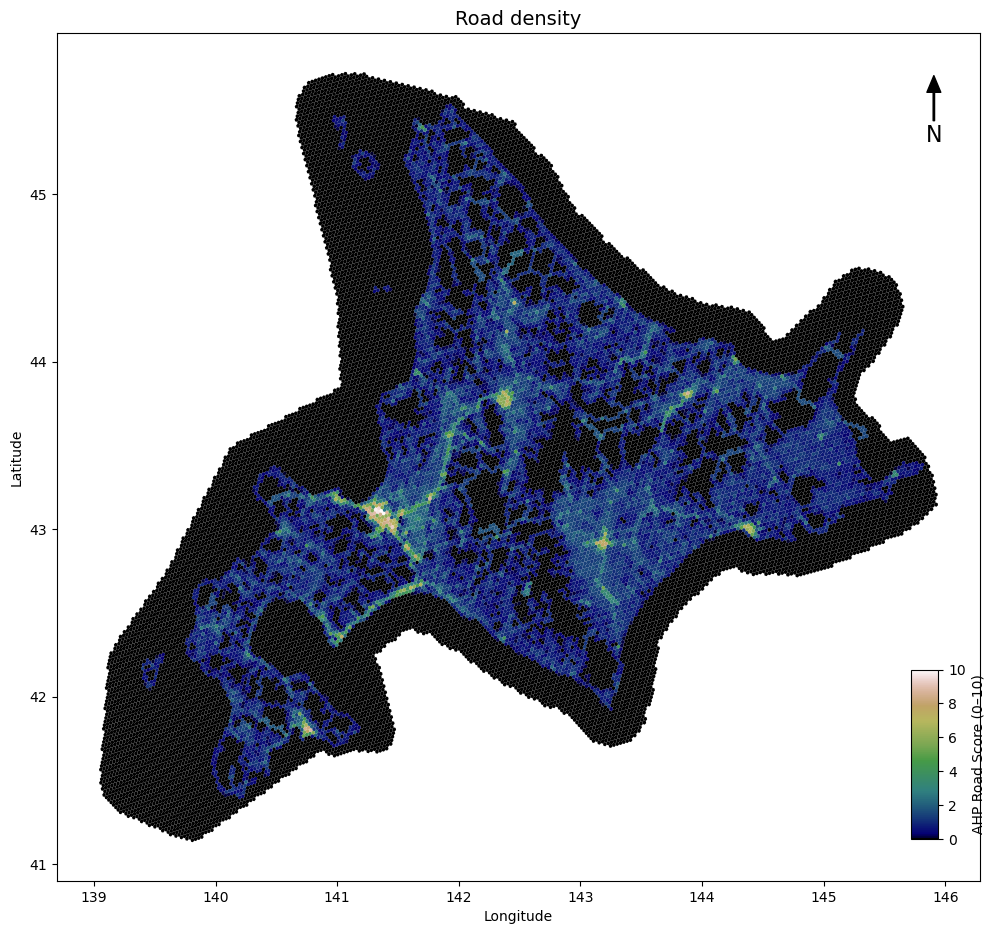

In [34]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

fig, ax = plt.subplots(figsize=(10, 10))

# Plot normalized road_score
regions.plot(
    column='road_score',
    cmap='gist_earth',
    ax=ax,
    legend=False,
    edgecolor='none'
)

# Add internal colorbar
sm = plt.cm.ScalarMappable(
    cmap='gist_earth',
    norm=plt.Normalize(vmin=0, vmax=10)
)
sm._A = []  # dummy array for ScalarMappable

cax = inset_axes(ax, width="3%", height="20%", loc='lower right', borderpad=3)
cbar = fig.colorbar(sm, cax=cax, orientation='vertical')
cbar.set_label("AHP Road Score (0–10)")

# Final touches
ax.set_title("Road density", fontsize=14)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

# Add north arrow
ax.annotate('N', xy=(0.95, 0.95), xytext=(0.95, 0.88), xycoords='axes fraction',
            ha='center', va='center', fontsize=16,
            arrowprops=dict(facecolor='black', width=1, headwidth=10))

plt.tight_layout()
plt.show()


In [37]:
regions.head()

,geometry,road_length_km,area_km2,road_density_km_per_km2,road_score
region_id,,,,,
872e1bb05ffffff,"POLYGON ((141.02832 42.42758, 141.02413 42.439...",0.000000,NaN,NaN,0.000000
872ef415effffff,"POLYGON ((141.48608 43.86309, 141.48187 43.875...",0.000000,NaN,NaN,0.000000
872ef4690ffffff,"POLYGON ((141.4078 44.51549, 141.40353 44.5276...",0.000000,NaN,NaN,0.000000
872e1e645ffffff,"POLYGON ((143.06589 42.7557, 143.06197 42.7681...",32.422189,NaN,NaN,1.551026
872ea9cb2ffffff,"POLYGON ((143.58632 44.41595, 143.58238 44.428...",0.000000,NaN,NaN,0.000000


In [36]:
# Select only the needed columns to match the structure of landcover
road_score_gdf = regions[["road_score", "geometry"]].copy()

# Set 'region_id' as a column (not index) if it's currently the index
road_score_gdf["region_id"] = road_score_gdf.index

# Reorder columns to match landcover structure
road_score_gdf = road_score_gdf[["region_id", "road_score", "geometry"]]


In [40]:
road_score_gdf.head()

,region_id,road_score,geometry
0,872e1bb05ffffff,0.000000,"POLYGON ((141.02832 42.42758, 141.02413 42.439..."
1,872ef415effffff,0.000000,"POLYGON ((141.48608 43.86309, 141.48187 43.875..."
2,872ef4690ffffff,0.000000,"POLYGON ((141.4078 44.51549, 141.40353 44.5276..."
3,872e1e645ffffff,1.551026,"POLYGON ((143.06589 42.7557, 143.06197 42.7681..."
4,872ea9cb2ffffff,0.000000,"POLYGON ((143.58632 44.41595, 143.58238 44.428..."


In [39]:
# Reset index so it's 0,1,2,... and turn 'region_id' from index to a column
road_score_gdf = regions.reset_index()[["region_id", "road_score", "geometry"]]


In [42]:
#save to file
road_score_gdf.to_file("ahp_road_density.geojson", driver="GeoJSON")